
# Brazilian Airline Historical Series Analysis

#### Frederico Horst

### Data Sources:
- Historical domestic air fares by origin, destination and airline: available at [ANAC website](https://www.anac.gov.br/acesso-a-informacao/dados-abertos/areas-de-atuacao/todos-os-dados-abertos). Files used here are under the title "Voos e operações aéreas - Tarifas aéreas domésticas - filtros para acesso aos arquivos CSV"
- Inflation data, using IPCA index: available at [IBGE website](https://www.ibge.gov.br/estatisticas/economicas/precos-e-custos/9256-indice-nacional-de-precos-ao-consumidor-amplo.html?=&t=series-historicas)
- More information on air fares on [ANAC website](https://www.anac.gov.br/)


In [1]:
from files_processor import FilesProcessor

df, metrics, route_variability = FilesProcessor().process_files()
df = None
metrics.head(15)


/Users/fred/Projects/flight-fares-analysis/files_processor.py:121: RuntimeWarning: invalid value encountered in scalar divide
  variance = (weights * (values - average) ** 2).sum() / (weights.sum() - 1)


/Users/fred/Projects/flight-fares-analysis/files_processor.py:121: RuntimeWarning: invalid value encountered in scalar divide
  variance = (weights * (values - average) ** 2).sum() / (weights.sum() - 1)


,RouteAgg,Route,YearMonth,WeightedAverageFare,FareStdDev,TotalSeats,CoefficientVariation,IPCAIndex,WeightedAverageFareReal,FareStdDevReal
0,AJU >> BEL,AJU >> BEL,2010-07,517.963648,245.339151,159.0,0.473661,3111.05,1272.020689,602.506521
1,AJU >> BEL,AJU >> BEL,2010-08,474.473939,239.542604,165.0,0.504859,3112.29,1164.753949,588.036921
2,AJU >> BEL,AJU >> BEL,2010-09,586.108156,254.796107,141.0,0.434725,3126.29,1432.354077,622.680709
3,AJU >> BEL,AJU >> BEL,2010-10,496.748429,218.305165,191.0,0.439468,3149.74,1204.935173,529.530756
4,AJU >> BEL,AJU >> BEL,2010-11,477.686829,253.875096,205.0,0.531468,3175.88,1149.161501,610.742162
5,AJU >> BEL,AJU >> BEL,2010-12,316.785982,202.687740,224.0,0.639825,3195.89,757.314057,484.548822
6,AJU >> BEL,AJU >> BEL,2011-01,383.618131,261.305765,198.0,0.681161,3222.42,909.533849,619.539116
7,AJU >> BEL,AJU >> BEL,2011-02,526.375379,214.215954,145.0,0.406964,3248.20,1238.097055,503.861223
8,AJU >> BEL,AJU >> BEL,2011-03,444.167143,277.277417,189.0,0.624264,3273.86,1036.545117,647.077473
9,AJU >> BEL,AJU >> BEL,2011-04,540.949333,297.476856,150.0,0.549916,3299.07,1252.757307,688.911664


In [2]:
route_variability.sort_values(by='CoefficientVariation', ascending=False).head(5)

,RouteAgg,AverageFareReal,FareRealStdDev,MinFareReal,MaxFareReal,MonthsAvailable,TotalSeats,CoefficientVariation
8679,SBRP >> SBTC,69.659015,306.017536,2.102732,2144.093279,6.0,264.0,4.393079
6554,SBAX >> SNPD,229.385992,455.530764,64.768322,3918.818480,27.0,71.0,1.985870
2619,FOR >> SBMS,246.252821,358.629868,74.478557,4998.757652,47.0,1598.0,1.456348
6993,SBCN >> SBPB,1017.232527,1451.632288,367.418469,3976.827474,3.0,6.0,1.427041
4088,LDB >> MGF,195.351333,264.791065,43.835077,3787.027270,57.0,2235.0,1.355461


In [3]:
route_variability.sort_values(by='CoefficientVariation', ascending=True).head(5)

,RouteAgg,AverageFareReal,FareRealStdDev,MinFareReal,MaxFareReal,MonthsAvailable,TotalSeats,CoefficientVariation
8701,SBRP >> SNAB,613.605462,0.0,613.605462,613.605462,1.0,2.0,0.0
267,BEL >> SBTC,756.706361,0.0,756.706361,756.706361,1.0,2.0,0.0
8433,SBPJ >> SWHP,2346.846744,0.0,2346.846744,2346.846744,1.0,2.0,0.0
2196,CXJ >> SNPD,403.829550,0.0,403.829550,403.829550,1.0,2.0,0.0
9660,SLZ >> SSFB,677.424966,0.0,677.424966,677.424966,1.0,8.0,0.0


## Are fares getting more expensive over time?

Approach: build a seats-weighted national fare index by year — nominal and real (IPCA-deflated) —
from `metrics`, then test whether the trend is statistically significant (OLS slope on year).

**The 2009→2010 jump is a dated methodology change, not noise.** [ANAC Resolution 140/2010](https://www.gov.br/anac/pt-br/assuntos/regulados/empresas-aereas/Instrucoes-para-a-elaboracao-e-apresentacao-das-demonstracoes-contabeis/base-de-dados-estatisticos-do-transporte-aereo)
took effect in July 2010 and expanded fare monitoring to *all* domestic routes; before that, ANAC
published a narrower panel (the "Fare Yield Report", Jan 2002–Sep 2009). This shows up exactly on
schedule in the data: reported routes jump from ~65 to ~2,000+ between June and July 2010. A
national average spanning both eras is really comparing two different sampling methodologies, not
a clean price signal — so alongside the full-period trend, this notebook treats **2011-2025** (full
calendar years under the new, consistent methodology) as the more trustworthy window, and
cross-checks both with a fixed basket of routes present in every year.

Data now runs from Jan 2002 through May 2026 with no gaps; 2026 is excluded from the yearly
aggregation below since it's a partial year.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

metrics['Year'] = metrics['YearMonth'].str[:4].astype(int)

def weighted_average(values, weights):
    return (values * weights).sum() / weights.sum()

yearly = metrics[metrics['Year'] < 2026].groupby('Year').apply(lambda x: pd.Series({
    'AvgFareNominal': weighted_average(x['WeightedAverageFare'], x['TotalSeats']),
    'AvgFareReal': weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']),
    'RoutesReporting': x['RouteAgg'].nunique(),
}), include_groups=False).reset_index()
yearly


,Year,AvgFareNominal,AvgFareReal,RoutesReporting
0,2002,271.863695,1092.572666,63.0
1,2003,344.736919,1208.515390,57.0
2,2004,386.021970,1268.889050,75.0
3,2005,395.520775,1220.454915,67.0
4,2006,376.994494,1116.618607,67.0
5,2007,286.604523,817.832028,68.0
6,2008,417.739408,1127.160856,66.0
7,2009,315.432904,813.427614,66.0
8,2010,272.465600,665.147400,2608.0
9,2011,269.871732,620.092991,3317.0


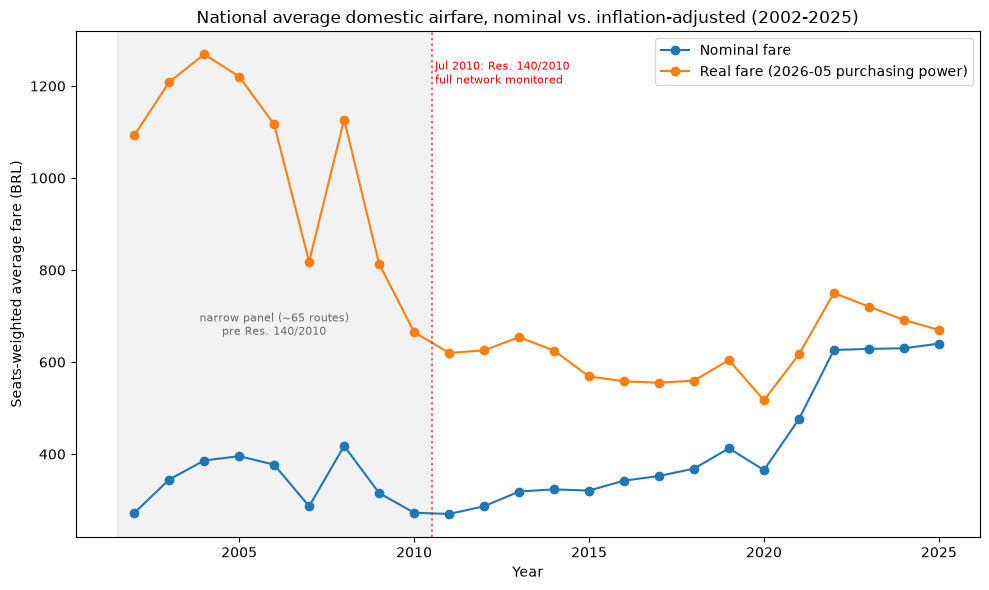

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yearly['Year'], yearly['AvgFareNominal'], marker='o', label='Nominal fare')
ax.plot(yearly['Year'], yearly['AvgFareReal'], marker='o',
        label=f"Real fare ({metrics['YearMonth'].max()} purchasing power)")
ax.axvspan(2001.5, 2010.5, color='grey', alpha=0.1)
ax.text(2006, yearly['AvgFareNominal'].max() * 1.03,
        'narrow panel (~65 routes)\npre Res. 140/2010', ha='center', fontsize=8, color='dimgrey')
ax.axvline(2010.5, color='red', linestyle=':', alpha=0.6)
ax.text(2010.6, yearly['AvgFareReal'].max() * 0.95,
        'Jul 2010: Res. 140/2010\nfull network monitored', fontsize=8, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Seats-weighted average fare (BRL)')
ax.set_title('National average domestic airfare, nominal vs. inflation-adjusted (2002-2025)')
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
def trend_test(data, ycol, label):
    """OLS slope of ycol on Year: direction, fit and significance of the trend."""
    slope, intercept, r, p, se = stats.linregress(data['Year'], data[ycol])
    sig = 'significant' if p < 0.05 else 'not significant'
    print(f"{label}:\n  {slope:+.2f} BRL/year, R²={r**2:.3f}, p={p:.4f} ({sig} at 5%)\n")

trend_test(yearly, 'AvgFareNominal', 'Nominal fare, full period 2002-2025')
trend_test(yearly, 'AvgFareReal', 'Real fare, full period 2002-2025')
trend_test(yearly[yearly['Year'] >= 2011], 'AvgFareReal', 'Real fare, 2011-2025 (post Res. 140/2010, consistent methodology)')


Nominal fare, full period 2002-2025:
  +11.72 BRL/year, R²=0.476, p=0.0002 (significant at 5%)

Real fare, full period 2002-2025:
  -25.96 BRL/year, R²=0.555, p=0.0000 (significant at 5%)

Real fare, 2011-2025 (post Res. 140/2010, consistent methodology):
  +6.03 BRL/year, R²=0.167, p=0.1302 (not significant at 5%)



### Controlling for route-mix: fixed basket check

The trend above is computed over whichever routes happened to report each year. To check it isn't
an artifact of the route-mix shift around 2010, recompute the same seats-weighted real fare index
restricting to a **fixed basket** of routes present in *every* year of a window — same routes,
every year, so any remaining trend can't be explained by which routes are being averaged. This is
done both for the full 2002-2025 span and for the more trustworthy 2011-2025 span.


In [7]:
years_all = sorted(yearly['Year'].unique())
years_recent = [y for y in years_all if y >= 2011]
route_years = metrics[metrics['Year'] < 2026].groupby('RouteAgg')['Year'].apply(set)

basket_full = route_years[route_years.apply(lambda s: set(years_all).issubset(s))].index
basket_recent = route_years[route_years.apply(lambda s: set(years_recent).issubset(s))].index
print(f"Routes reporting every year 2002-2025: {len(basket_full)}")
print(f"Routes reporting every year 2011-2025: {len(basket_recent)}")

fixed_full = metrics[metrics['RouteAgg'].isin(basket_full) & (metrics['Year'] < 2026)].groupby('Year').apply(
    lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
).rename('FixedBasketFareReal').reset_index()

fixed_recent = metrics[metrics['RouteAgg'].isin(basket_recent) & (metrics['Year'] >= 2011) & (metrics['Year'] < 2026)].groupby('Year').apply(
    lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
).rename('FixedBasketFareReal').reset_index()

print()
trend_test(fixed_full, 'FixedBasketFareReal', f'Real fare, fixed basket of {len(basket_full)} routes, full period 2002-2025')
trend_test(fixed_recent, 'FixedBasketFareReal', f'Real fare, fixed basket of {len(basket_recent)} routes, 2011-2025')


Routes reporting every year 2002-2025: 44
Routes reporting every year 2011-2025: 1838



Real fare, fixed basket of 44 routes, full period 2002-2025:
  -33.72 BRL/year, R²=0.664, p=0.0000 (significant at 5%)

Real fare, fixed basket of 1838 routes, 2011-2025:
  +5.78 BRL/year, R²=0.154, p=0.1480 (not significant at 5%)



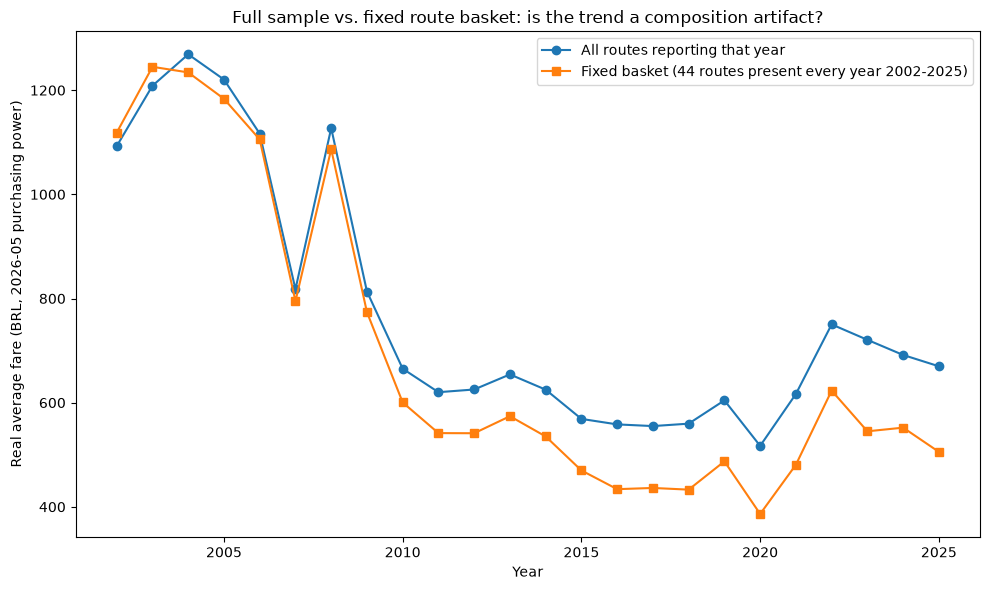

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yearly['Year'], yearly['AvgFareReal'], marker='o', label='All routes reporting that year')
ax.plot(fixed_full['Year'], fixed_full['FixedBasketFareReal'], marker='s',
        label=f'Fixed basket ({len(basket_full)} routes present every year 2002-2025)')
ax.set_xlabel('Year')
ax.set_ylabel(f"Real average fare (BRL, {metrics['YearMonth'].max()} purchasing power)")
ax.set_title('Full sample vs. fixed route basket: is the trend a composition artifact?')
ax.legend()
plt.tight_layout()
plt.show()


### Findings

- **Full period (2002-2025)**: real (inflation-adjusted) average fares are significantly lower now
  than in the 2002-2009 era — both in the full sample and in a fixed basket of the 44 routes
  present every year, so it isn't just a composition effect from adding cheaper regional routes
  after 2010. Nominal fares actually *rose* significantly over the same period (+R$12/year), so
  this finding depends entirely on deflating by IPCA.
- **Since the methodology stabilized (2011-2025)**: there is **no statistically significant trend**
  in real fares, either in the full sample or a fixed basket of 1,838 routes present every year
  since 2011 (p ≈ 0.13-0.15). Real fares moved in a roughly R$550-750 band — dipping in 2020
  (pandemic), spiking in 2022-2023, easing back in 2024-2025 — with no persistent up or down drift
  once the narrow pre-2010 panel is excluded.
- **Bottom line**: comparing today to 2002 in isolation suggests fares got cheaper, but most of
  that gap is explained by the July 2010 jump from a narrow trunk-route panel to full network
  monitoring (Resolution 140/2010), not a smooth multi-year price decline. Over the 15 years ANAC
  has consistently monitored the whole domestic network (2011-2025), real fares have essentially
  been flat, with no significant secular trend in either direction.

**Caveats**: this is a seats-weighted average across all reported routes/carriers, so it says
nothing about any specific route's price path (see `route_fare_variability.csv` / the
coefficient-of-variation cells above for route-level spread); 2026 is excluded as a partial year
(data available through May 2026 only).


## Are the busiest routes getting more expensive?

The national index averages over route-mix changes; here the same trend test is applied to each
of the 5 busiest routes individually (by total seats sold, 2002-2025), using only real
(IPCA-deflated) fares. Same caveat as the national analysis applies: the 2009→2010 methodology
break means the full-period trend and the 2011-2025 trend can tell different stories, so both are
reported per route.


In [9]:
import pandas
import os

metrics = pandas.read_csv(os.getcwd() + "/metrics_files/fare_metrics_by_year_deflated.csv", sep=",", encoding="utf-8")
metrics['Year'] = metrics['YearMonth'].str[:4].astype(int)
metrics = metrics[metrics['Year'] < 2026]

route_seats = metrics.groupby('RouteAgg')['TotalSeats'].sum().reset_index()
route_seats = route_seats.sort_values('TotalSeats', ascending=False)
top5_routes = route_seats.head(5)['RouteAgg'].tolist()
route_seats.head(5)


,RouteAgg,TotalSeats
1304,CGH >> SDU,41567331.0
534,BSB >> CGH,16380724.0
3024,GRU >> SSA,15577531.0
1223,CGH >> POA,13581038.0
2913,GRU >> REC,12698846.0


In [10]:
top5_yearly = {}
for route in top5_routes:
    sub = metrics[metrics['RouteAgg'] == route]
    route_yearly = sub.groupby('Year').apply(
        lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
    ).rename('AvgFareReal').reset_index()
    top5_yearly[route] = route_yearly

    print(f"=== {route} ({sub['TotalSeats'].sum():,.0f} total seats, {len(route_yearly)} years of data) ===")
    trend_test(route_yearly, 'AvgFareReal', f'{route}, full period 2002-2025')
    trend_test(route_yearly[route_yearly['Year'] >= 2011], 'AvgFareReal', f'{route}, 2011-2025')


=== CGH >> SDU (41,567,331 total seats, 24 years of data) ===
CGH >> SDU, full period 2002-2025:
  -29.59 BRL/year, R²=0.662, p=0.0000 (significant at 5%)

CGH >> SDU, 2011-2025:
  -14.29 BRL/year, R²=0.264, p=0.0503 (not significant at 5%)

=== BSB >> CGH (16,380,724 total seats, 24 years of data) ===
BSB >> CGH, full period 2002-2025:
  -46.52 BRL/year, R²=0.796, p=0.0000 (significant at 5%)

BSB >> CGH, 2011-2025:
  -16.75 BRL/year, R²=0.508, p=0.0029 (significant at 5%)

=== GRU >> SSA (15,577,531 total seats, 24 years of data) ===
GRU >> SSA, full period 2002-2025:
  -64.08 BRL/year, R²=0.596, p=0.0000 (significant at 5%)

GRU >> SSA, 2011-2025:
  +5.75 BRL/year, R²=0.093, p=0.2688 (not significant at 5%)

=== CGH >> POA (13,581,038 total seats, 24 years of data) ===
CGH >> POA, full period 2002-2025:
  -43.50 BRL/year, R²=0.692, p=0.0000 (significant at 5%)

CGH >> POA, 2011-2025:
  -3.45 BRL/year, R²=0.036, p=0.4990 (not significant at 5%)

=== GRU >> REC (12,698,846 total seats

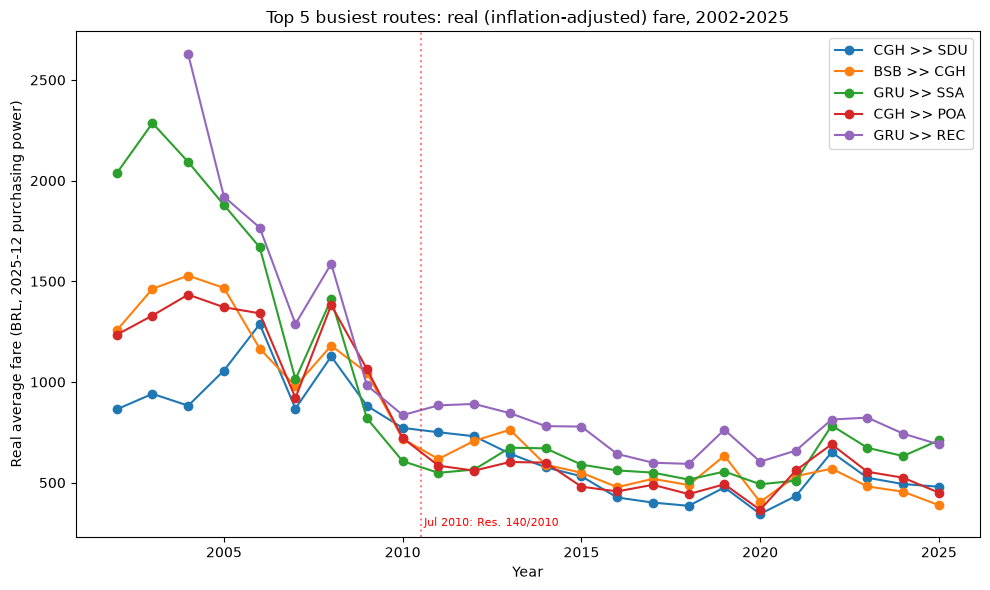

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
for route in top5_routes:
    route_yearly = top5_yearly[route]
    ax.plot(route_yearly['Year'], route_yearly['AvgFareReal'], marker='o', label=route)
ax.axvline(2010.5, color='red', linestyle=':', alpha=0.5)
ax.text(2010.6, ax.get_ylim()[1] * 0.02 + ax.get_ylim()[0], 'Jul 2010: Res. 140/2010', fontsize=8, color='red')
ax.set_xlabel('Year')
ax.set_ylabel(f"Real average fare (BRL, {metrics['YearMonth'].max()} purchasing power)")
ax.set_title('Top 5 busiest routes: real (inflation-adjusted) fare, 2002-2025')
ax.legend()
plt.tight_layout()
plt.show()


### Findings: top 5 busiest routes

- **Full period (2002-2025)**: all five routes show a significant real-price decline
  (roughly -30 to -64 BRL/year, p<0.0001) — same pattern as the national index, and subject to the
  same 2010 methodology-break caveat (these routes were part of the original narrow panel too, so
  the pre/post-2010 comparison is at least apples-to-apples on *route identity*, if not on the
  broader market context).
- **Since 2011**: results diverge by route. BSB >> CGH (Brasília–São Paulo/Congonhas) shows a
  significant decline (-16.75 BRL/year, p=0.003). CGH >> SDU (the São Paulo–Rio "air bridge", the
  single busiest route in the dataset) is borderline (-14.29 BRL/year, p=0.05). GRU >> SSA,
  CGH >> POA and GRU >> REC show no significant trend either way.
- Unlike the flat national aggregate since 2011, the busiest trunk routes lean toward getting
  *cheaper* rather than more expensive — plausibly reflecting the higher competition and flight
  frequency on these specific corridors, though this notebook doesn't test that mechanism
  directly.


## Testing that claim: top 5 combined vs. every other route combined

The individual-route trends above are suggestive but noisy (small per-route samples, one trend
line each). A sharper test: build two seats-weighted real fare indices — one over just the top 5
routes combined, one over every other route combined — and run the same trend test on each. If the
"busiest routes lean cheaper" claim holds, the two indices should diverge since 2011: negative
slope for the top 5, flat-or-positive for everyone else.


In [12]:
is_top5 = metrics['RouteAgg'].isin(top5_routes)

top5_combined_yearly = metrics[is_top5].groupby('Year').apply(
    lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
).rename('AvgFareReal').reset_index()

others_combined_yearly = metrics[~is_top5].groupby('Year').apply(
    lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
).rename('AvgFareReal').reset_index()

trend_test(top5_combined_yearly, 'AvgFareReal', 'Top 5 combined, full period 2002-2025')
trend_test(top5_combined_yearly[top5_combined_yearly['Year'] >= 2011], 'AvgFareReal', 'Top 5 combined, 2011-2025')
trend_test(others_combined_yearly, 'AvgFareReal', 'All other routes combined, full period 2002-2025')
trend_test(others_combined_yearly[others_combined_yearly['Year'] >= 2011], 'AvgFareReal', 'All other routes combined, 2011-2025')

# fixed-basket version of "all other routes", to rule out composition effects the same way as before
others_basket = [r for r in basket_recent if r not in top5_routes]
others_fixed_yearly = metrics[metrics['RouteAgg'].isin(others_basket) & (metrics['Year'] >= 2011)].groupby('Year').apply(
    lambda x: weighted_average(x['WeightedAverageFareReal'], x['TotalSeats']), include_groups=False
).rename('AvgFareReal').reset_index()
print(f"'Other routes' fixed basket: {len(others_basket)} routes present every year 2011-2025")
trend_test(others_fixed_yearly, 'AvgFareReal', f'Other routes, fixed basket of {len(others_basket)}, 2011-2025')


Top 5 combined, full period 2002-2025:
  -37.49 BRL/year, R²=0.729, p=0.0000 (significant at 5%)

Top 5 combined, 2011-2025:
  -9.88 BRL/year, R²=0.249, p=0.0582 (not significant at 5%)

All other routes combined, full period 2002-2025:
  -23.38 BRL/year, R²=0.509, p=0.0001 (significant at 5%)

All other routes combined, 2011-2025:
  +7.83 BRL/year, R²=0.263, p=0.0504 (not significant at 5%)

'Other routes' fixed basket: 1833 routes present every year 2011-2025
Other routes, fixed basket of 1833, 2011-2025:
  +7.69 BRL/year, R²=0.254, p=0.0554 (not significant at 5%)



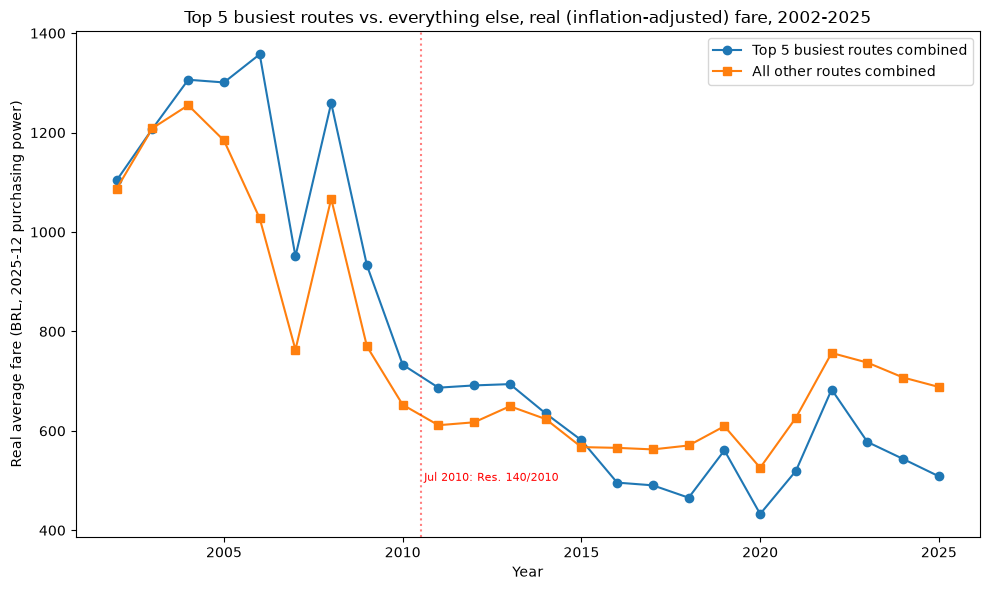

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(top5_combined_yearly['Year'], top5_combined_yearly['AvgFareReal'], marker='o', label='Top 5 busiest routes combined')
ax.plot(others_combined_yearly['Year'], others_combined_yearly['AvgFareReal'], marker='s', label='All other routes combined')
ax.axvline(2010.5, color='red', linestyle=':', alpha=0.5)
ax.text(2010.6, others_combined_yearly['AvgFareReal'].min() * 0.95, 'Jul 2010: Res. 140/2010', fontsize=8, color='red')
ax.set_xlabel('Year')
ax.set_ylabel(f"Real average fare (BRL, {metrics['YearMonth'].max()} purchasing power)")
ax.set_title('Top 5 busiest routes vs. everything else, real (inflation-adjusted) fare, 2002-2025')
ax.legend()
plt.tight_layout()
plt.show()


### Findings: top 5 vs. everyone else

- **Since 2011, the two groups move in opposite directions**: top 5 combined at -9.88 BRL/year
  (p=0.058), all other routes combined at +7.83 BRL/year (p=0.050). A fixed basket of 1,833 "other"
  routes present every year since 2011 gives essentially the same result (+7.69 BRL/year,
  p=0.055), so this isn't route-mix noise in the "others" group either.
- **Read the p-values honestly**: both individual trends sit right at the conventional p<0.05
  cutoff, not comfortably past it — so neither slope, on its own, is strong evidence of a real
  trend. What's more convincing is the *contrast*: two large, independently-constructed
  seats-weighted indices, both borderline-significant, pointing in opposite directions. That's
  consistent with the earlier claim (busiest trunk routes trending cheaper, the rest of the
  network flat-to-pricier) — but it should be read as suggestive, not conclusive, given how close
  both trends sit to the significance threshold.
- This also explains why the *national* aggregate looked flat since 2011 (+6.03 BRL/year, not
  significant, from the earlier section): it's an average of a slightly-declining top 5 and a
  slightly-rising everyone-else, which can wash out to "no trend" even if both underlying groups
  are doing something.


## Discussion: "cheaper fares" vs. what actually happened to the cost of flying

Everything above measures the **base fare only** — `Fare` in ANAC's `tarifas aéreas domésticas`
dataset has always been just origin/destination/airline/price/seats. It has never included
checked baggage, seat selection, or any other add-on, in any year of this series.

That matters because of a specific, dated regulatory change: [ANAC Resolução 400/2016](https://www.gov.br/anac/pt-br/assuntos/regulados/empresas-aereas/repositorio-de-respostas-as-demandas-institucionais/resolucao-no-400-de-13-12-2016)
(published Dec 13, 2016, **effective March 15, 2017**) unbundled air travel: airlines only had to
guarantee 10 kg of free carry-on; checked baggage and seat selection became opt-in, chargeable
extras. It was explicitly justified as opening the market to low-cost carriers and, in the
resolution's own stated rationale, leading to a "decrease in fares" — the promise this section
is checking. It was controversial enough that the Brazilian bar association (OAB) ran a
consumer-rights campaign, "Bagagem sem preço" ("Baggage without a price"), against it.

**What the fare data alone shows**: nationally, real (IPCA-deflated) fares from 2011-2025 show no
statistically significant trend (p≈0.13, see the first "Findings" section above) — flat, not down.
So even on its own terms, the "fares will fall" promise doesn't show up in the base-fare series
either.

**What's missing from that picture**: ANAC does track ancillary revenue, but as a completely
separate product — the *Anuário do Transporte Aéreo, Volume II – Dados Econômicos*, published
annually at the company level (not per route/month, and not merged into the fare panel used in
this notebook). Press coverage citing ANAC's own published figures reports that Azul, Gol and
Latam together collected **R$1.9 billion in ancillary fees in 2024** (R$1.1bi from checked
baggage, R$860mi from seat selection) — the highest since that series began in 2015, and still
climbing in early 2025. That revenue is real money passengers are paying that never appears in
the `Fare` column analyzed here.

**Conclusion**: on the numbers this notebook can actually compute, base fares did not get more
expensive since the unbundling took effect — but they didn't get meaningfully cheaper either,
contrary to the stated promise. Layered with a real, growing, separately-billed ancillary revenue
stream that used to be bundled into the ticket price, it's a reasonable inference that the
all-in cost of flying — for anyone who needs a checked bag, a specific seat, or extra legroom,
which is most travelers on anything but a short trip with only a personal item — has not fallen,
and plausibly rose, even though the base fare alone looks flat.

**This is a sourced discussion point, not a quantified finding**: this notebook does not have
per-route ancillary-fee data to add to the fare index, since ANAC publishes it as annual
company-level totals in per-year ZIP/PDF archives rather than a queryable series like the fare
panel. A rigorous version of this analysis would pull and standardize several years of the
Anuário Volume II archives and merge them in — a separate, larger task from what's done here.
